In [32]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering_invariant import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import seaborn as sns

In [28]:
df = pd.read_csv("/Users/judydw/Downloads/pval_data_randomized-3.csv")
df2 = pd.read_csv("/Users/judydw/Downloads/pval_data.csv")

In [25]:
df

,tau=0.01,tau=0.05,tau=0.1,tau=0.5,tau=1,tau=5,naive
0,0.216958,0.639013,0.177758,0.047514,0.208026,0.424621,1.900996e-03
1,0.541798,0.511564,0.893475,0.559644,0.693621,0.775714,4.743142e-05
2,0.134733,0.417168,0.414287,0.972721,0.408319,0.399113,2.264783e-02
3,0.490202,0.335068,0.130122,0.054079,0.680426,0.317576,5.909277e-04
4,0.908673,0.750038,0.520423,0.533257,0.888665,0.180211,1.212841e-07
...,...,...,...,...,...,...,...
495,0.500625,0.707244,0.329995,0.209261,0.176295,0.025023,8.287747e-03
496,0.501232,0.987770,0.126194,0.412641,0.614658,0.554569,3.110648e-06
497,0.746659,0.710856,0.101674,0.681669,0.943539,0.804317,2.836810e-02
498,0.668281,0.567469,0.621679,0.994430,0.507721,0.361594,5.812752e-05


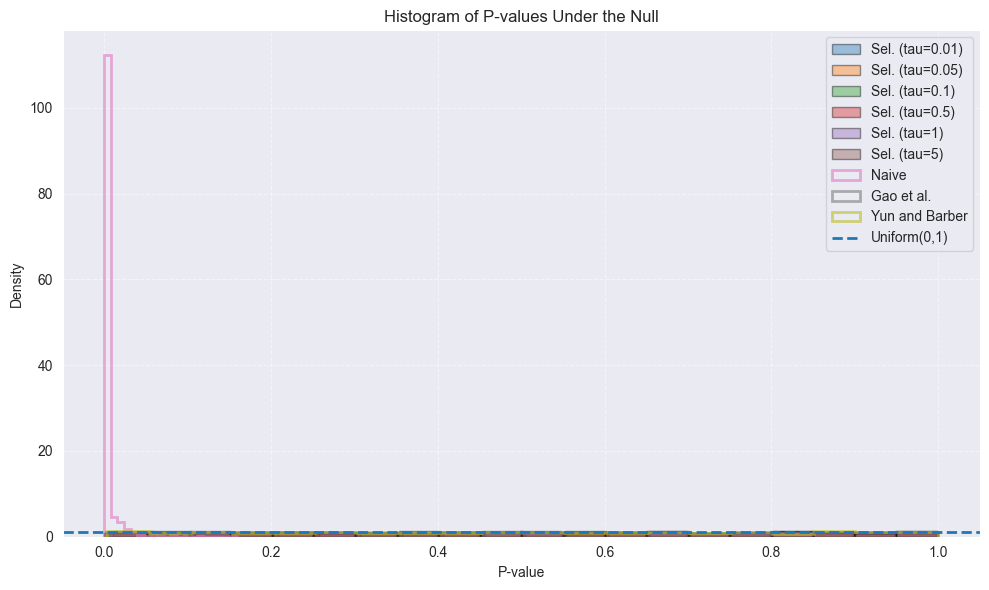

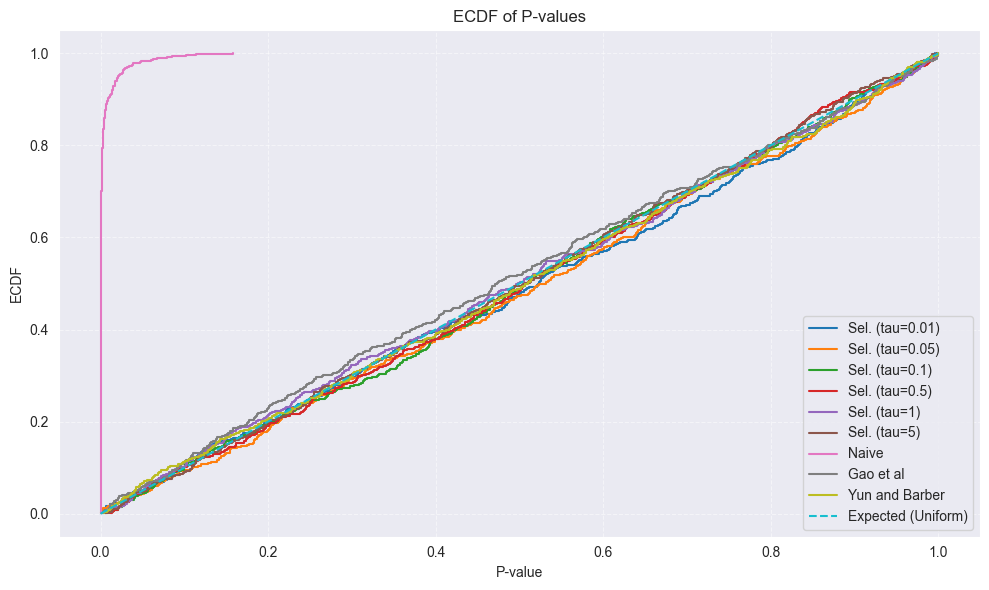

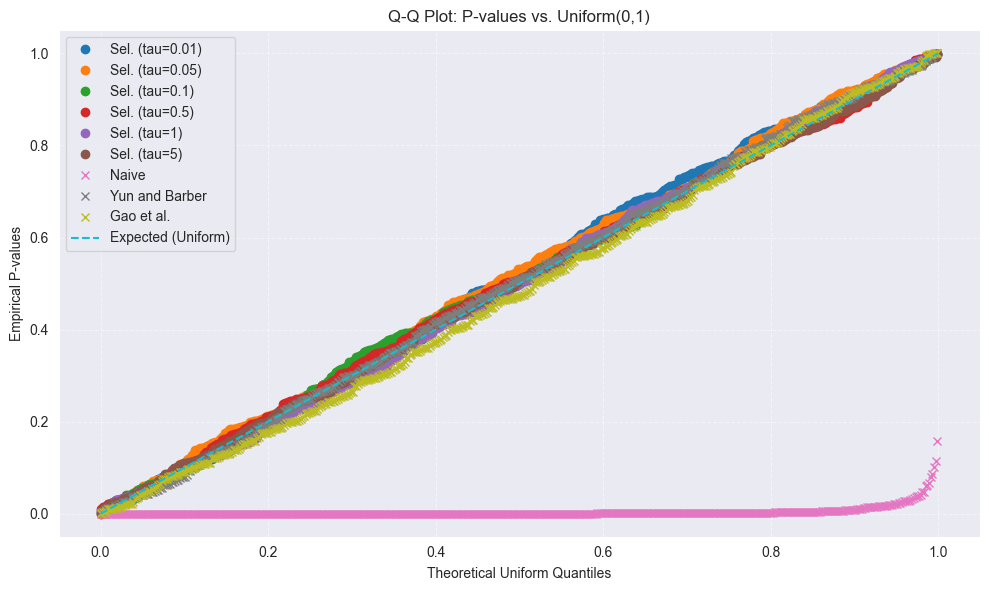

In [30]:
tau_cols = [c for c in df.columns if c.startswith('tau=')]
naive = df['naive'].dropna().to_numpy()
gao = df2['Gao']
barber = df2['Barber']
# ---------- 1) 直方图 ----------
plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = df[col].dropna().to_numpy()
    plt.hist(vals, bins=20, density=True, alpha=0.4, edgecolor='black',
             label=f"Sel. ({col})")
plt.hist(naive, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Naive")
plt.hist(gao, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Gao et al.")
plt.hist(barber, bins=20, density=True, alpha=0.6, histtype='step', linewidth=2,
         label="Yun and Barber")
plt.axhline(1, linestyle='--', linewidth=2, label="Uniform(0,1)")
plt.xlabel("P-value"); plt.ylabel("Density")
plt.title("Histogram of P-values Under the Null")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

# ---------- 2) ECDF ----------
def plot_ecdf(values, label):
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.step(x, y, where='post', label=label)

plt.figure(figsize=(10, 6))
for col in tau_cols:
    plot_ecdf(df[col].dropna().to_numpy(), f"Sel. ({col})")
plot_ecdf(naive, "Naive")
plot_ecdf(gao, "Gao et al")
plot_ecdf(barber, "Yun and Barber")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("P-value"); plt.ylabel("ECDF")
plt.title("ECDF of P-values")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
for col in tau_cols:
    vals = np.sort(df[col].dropna().to_numpy())
    n = len(vals)
    theo = (np.arange(1, n + 1) - 0.5) / n
    plt.plot(theo, vals, marker='o', linestyle='', label=f"Sel. ({col})")
vals_naive = np.sort(naive)
vals_barber = np.sort(barber)
vals_gao = np.sort(gao)
n0 = len(vals_naive)
theo0 = (np.arange(1, n0 + 1) - 0.5) / n0
plt.plot(theo0, vals_naive, marker='x', linestyle='', label="Naive")
plt.plot(theo0, vals_barber, marker='x', linestyle='', label="Yun and Barber")
plt.plot(theo0, vals_gao, marker='x', linestyle='', label="Gao et al.")
plt.plot([0, 1], [0, 1], linestyle="--", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend(); plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

In [37]:
type1_gao = pd.read_csv("/Users/judydw/Downloads/type1_gao_by_repeat.csv")
type1_barber = pd.read_csv("/Users/judydw/Downloads/type1_barber_by_repeat.csv")
type1 = pd.read_csv("/Users/judydw/Downloads/type1_error_results.csv")
alpha = 0.05

In [38]:
type1

,Tau,Type,Type I Error
0,0.0,Naive,0.985
1,0.0,Naive,0.990
2,0.0,Naive,0.985
3,0.0,Naive,1.000
4,0.0,Naive,0.990
...,...,...,...
895,10.0,Randomized,0.045
896,10.0,Randomized,0.055
897,10.0,Randomized,0.060
898,10.0,Randomized,0.060


/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_64040/3433161249.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)


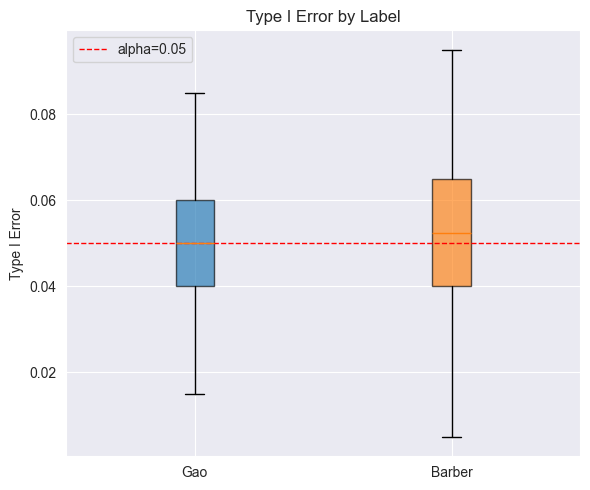

In [36]:
df = pd.concat([type1_gao, type1_barber], ignore_index=True)
df = df.dropna(subset=['Type I Error', 'Label'])

order = ['Gao','Barber'] if {'Gao','Barber'}.issubset(set(df['Label'])) \
        else sorted(df['Label'].unique())
palette = {'Gao':'#1f77b4', 'Barber':'#ff7f0e'}  
colors = [palette.get(lbl, 'lightgray') for lbl in order]

data = [df.loc[df['Label']==lbl, 'Type I Error'].to_numpy() for lbl in order]

fig, ax = plt.subplots(figsize=(6,5))
bp = ax.boxplot(data, labels=order, showfliers=False, patch_artist=True)
for box, c in zip(bp['boxes'], colors):
    box.set_facecolor(c)
    box.set_alpha(0.65)

alpha = 0.05  # 如需显示参考线
ax.axhline(alpha, linestyle='--', linewidth=1, color='red', label=f'alpha={alpha}')
ax.set_ylabel('Type I Error')
ax.set_title('Type I Error by Label')
ax.legend()
plt.tight_layout()
# plt.savefig('type1_boxplot.png', dpi=200); plt.close()

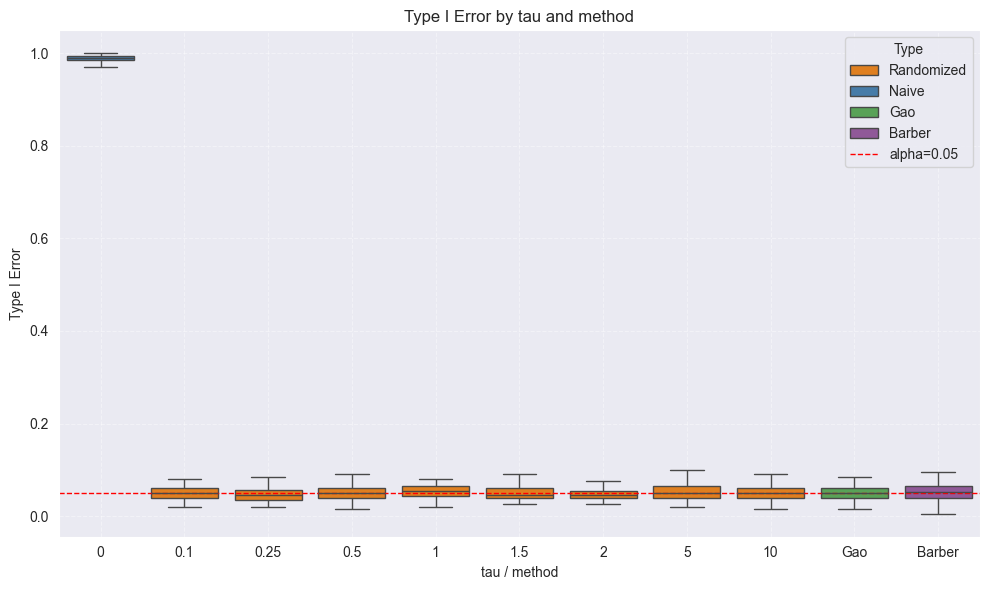

In [42]:
df_tau = type1.copy()
df_tau.loc[df_tau['Type'].str.lower() == 'naive', 'Tau'] = 0.0
df_tau['Group'] = df_tau['Tau'].astype(float).map(lambda x: f"{x:g}")
df_tau_plot = df_tau[['Group', 'Type', 'Type I Error']]
df_gb_plot = pd.concat([
    type1_gao.assign(Group='Gao',    Type='Gao')[['Group','Type','Type I Error']],
    type1_barber.assign(Group='Barber', Type='Barber')[['Group','Type','Type I Error']]
], ignore_index=True)

df_all = pd.concat([df_tau_plot, df_gb_plot], ignore_index=True)

def _is_float(s):
    try:
        float(s); return True
    except:
        return False

tau_groups = sorted([g for g in df_all['Group'].unique() if _is_float(g)],
                    key=lambda s: float(s))
order = tau_groups + [g for g in ['Gao','Barber'] if g in df_all['Group'].unique()]

hue_order = [h for h in ['Randomized','Naive','Gao','Barber'] if h in df_all['Type'].unique()]
palette = {
    'Randomized': '#FF7F00',  # red
    'Naive':      '#377EB8',  # blue
    'Gao':        '#4DAF4A',  # green
    'Barber':     '#984EA3',  # purple
}

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_all, x='Group', y='Type I Error',
    hue='Type', order=order, hue_order=hue_order,
    palette=palette, showfliers=False
)
plt.axhline(alpha, linestyle='--', linewidth=1, color='red', label=f'alpha={alpha}')
plt.xlabel('tau / method')
plt.title('Type I Error by tau and method')
plt.legend(title='Type')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figs/invariant/type1_by_tau_method_boxplot.png', dpi=200)
plt.show()